In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [11]:
import os
print("A pasta onde o Jupyter está a procurar é:")
print(os.getcwd())

A pasta onde o Jupyter está a procurar é:
C:\Users\imalp\Downloads


In [13]:

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(f"Dimensões dos dados de treino: {df_train.shape}")
print(f"Dimensões dos dados de teste: {df_test.shape}")
df_train.head()

Dimensões dos dados de treino: (1460, 81)
Dimensões dos dados de teste: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



Variáveis com mais valores nulos:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


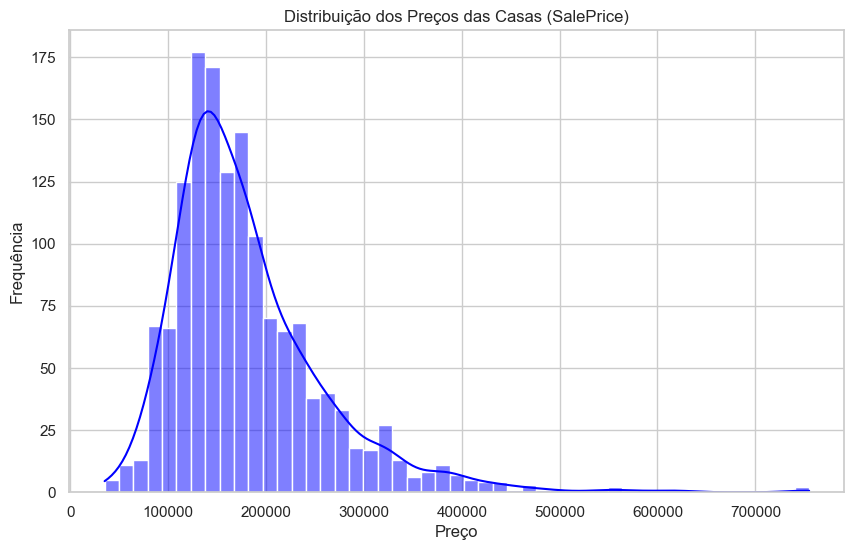

In [14]:
df_train.info()

display(df_train.describe())

null_counts = df_train.isnull().sum().sort_values(ascending=False)
print("\nVariáveis com mais valores nulos:")
print(null_counts[null_counts > 0].head(20))

plt.figure(figsize=(10, 6))
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title('Distribuição dos Preços das Casas (SalePrice)')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

In [15]:

df = df_train.copy()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['Id', 'SalePrice'])
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

cat_cols = df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Feature Engineering concluído. Dimensões de X_scaled:", X_scaled.shape)

Feature Engineering concluído. Dimensões de X_scaled: (1460, 79)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_reg))

print("--- Resultados do Modelo de Regressão (Random Forest) ---")
print(f"MAE (Erro Absoluto Médio): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}")

--- Resultados do Modelo de Regressão (Random Forest) ---
MAE (Erro Absoluto Médio): 17657.47
RMSE (Raiz do Erro Quadrático Médio): 28457.74


In [16]:
mediana_preco = y.median()
y_class = (y > mediana_preco).astype(int)

Xc_train, Xc_val, yc_train, yc_val = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(Xc_train, yc_train)

yc_pred = clf_model.predict(Xc_val)
print("--- Resultados do Modelo de Classificação (Casas acima da mediana) ---")
print(f"Accuracy: {accuracy_score(yc_val, yc_pred):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(yc_val, yc_pred))

--- Resultados do Modelo de Classificação (Casas acima da mediana) ---
Accuracy: 0.9555

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       161
           1       0.94      0.96      0.95       131

    accuracy                           0.96       292
   macro avg       0.95      0.96      0.96       292
weighted avg       0.96      0.96      0.96       292



In [17]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
print("Quantidade de casas por Cluster:")
print(df['Cluster'].value_counts())


preco_por_cluster = df.groupby('Cluster')['SalePrice'].mean().sort_values()
print("\nPreço Médio por Cluster:")
print(preco_por_cluster)

Quantidade de casas por Cluster:
Cluster
1    574
2    553
0    333
Name: count, dtype: int64

Preço Médio por Cluster:
Cluster
0    124043.909910
2    147677.481013
1    245945.430314
Name: SalePrice, dtype: float64


In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variância explicada pelas 2 componentes: {sum(pca.explained_variance_ratio_):.4f}")

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

Variância explicada pelas 2 componentes: 0.1843


In [19]:
iso_forest = IsolationForest(contamination=0.05, random_state=42) 
outliers = iso_forest.fit_predict(X_scaled)


df['Outlier'] = outliers
num_outliers = (df['Outlier'] == -1).sum()

print(f"Número de outliers detetados: {num_outliers}")

Número de outliers detetados: 73


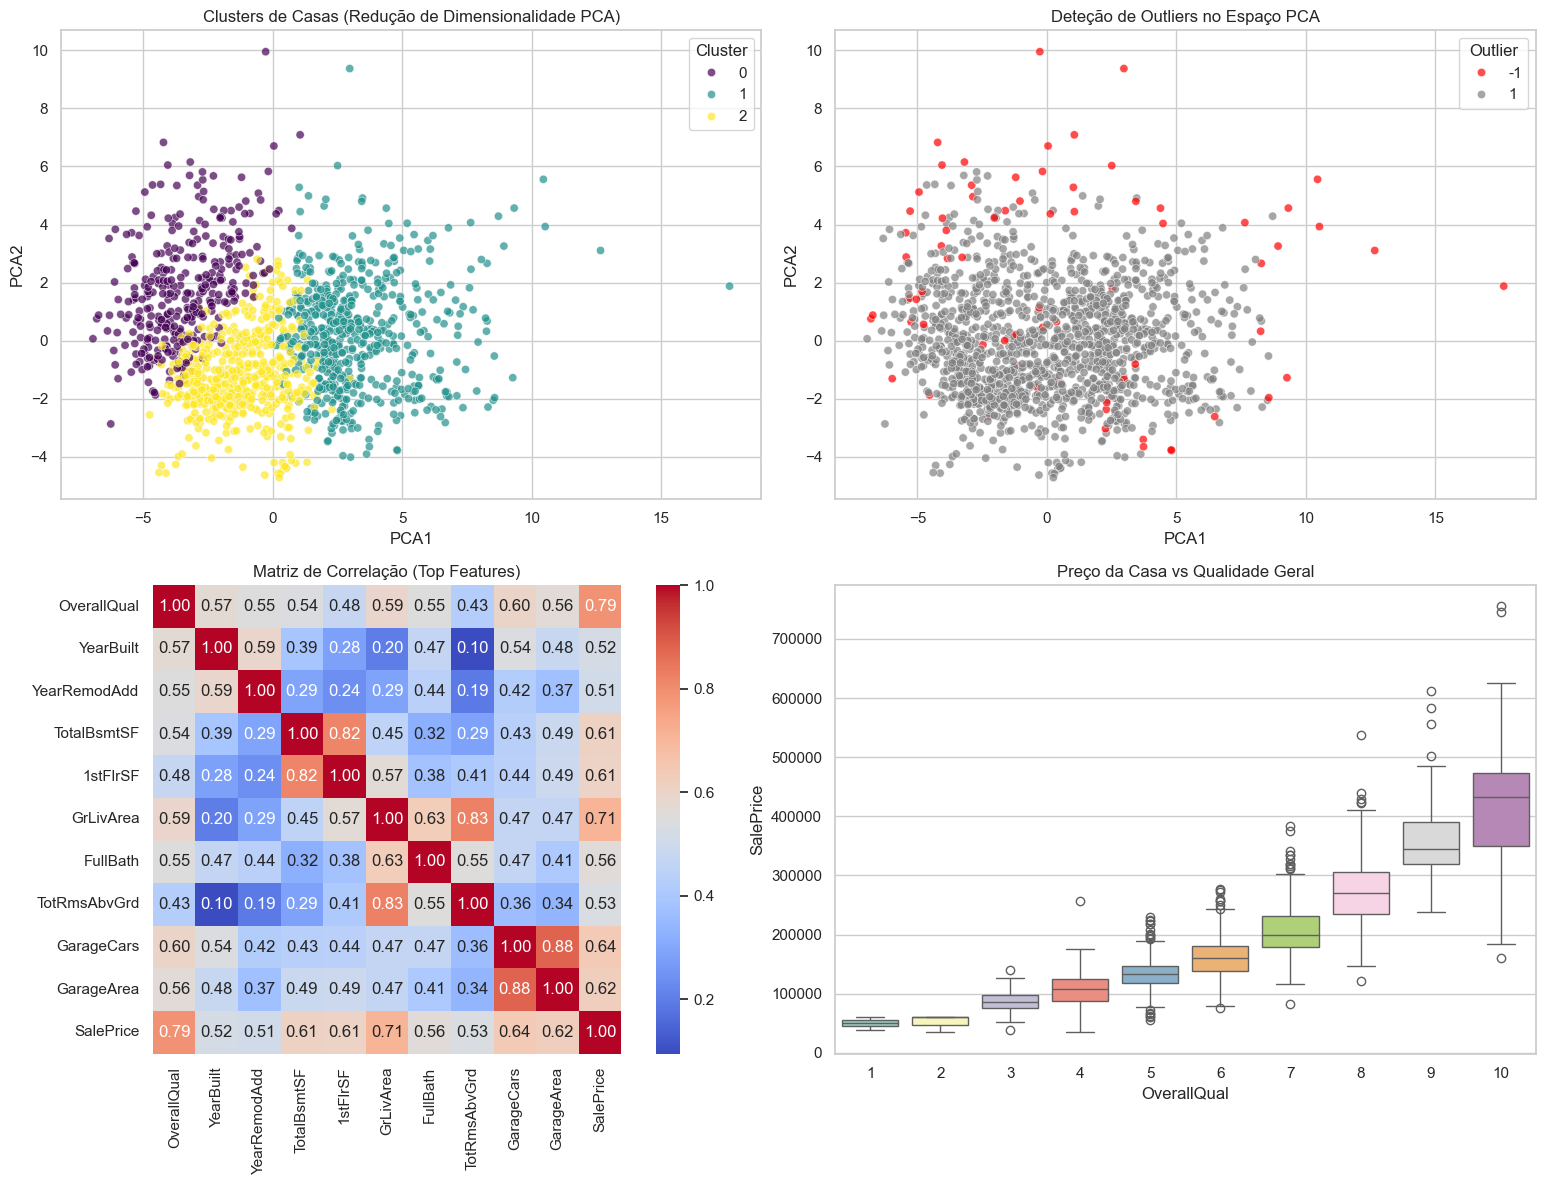

In [20]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=df, alpha=0.7)
plt.title('Clusters de Casas (Redução de Dimensionalidade PCA)')

plt.subplot(2, 2, 2)
sns.scatterplot(x='PCA1', y='PCA2', hue='Outlier', palette={1: 'gray', -1: 'red'}, data=df, alpha=0.7)
plt.title('Deteção de Outliers no Espaço PCA')

plt.subplot(2, 2, 3)
numeric_df = df_train.select_dtypes(include=[np.number])
corr = numeric_df.corr()
top_corr_features = corr.index[abs(corr["SalePrice"]) > 0.5]
sns.heatmap(numeric_df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt='.2f', square=True)
plt.title('Matriz de Correlação (Top Features)')

plt.subplot(2, 2, 4)
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, palette='Set3')
plt.title('Preço da Casa vs Qualidade Geral')

plt.tight_layout()
plt.show()